In [1]:
import numpy as np

# ============================================================
# Constants (cgs)
# ============================================================
AU   = 1.495978707e13
RSUN = 6.957e10
SIGMA_SB = 5.670374419e-5
PI = np.pi

# ============================================================
# User / model parameters (toy Dullemond-like)
# ============================================================
Teff   = 3000.0
Rstar  = 2.0 * RSUN

Sigma_1AU = 10.
pSigma    = 1.0

R = 50 * AU
Sigma = Sigma_1AU * (R / AU) ** (-pSigma)

# Prescribed Gaussian density scale height (NOT iterated)
Hscale = 0.1 * R

# Eddington/Marshak boundary parameter (Two stream approximation)
psi = 1.0 / np.sqrt(3.0)

# Grazing beam
mu0 = 0.05

# Grid
nz = 800
zmax = 12.0 * Hscale
p_stretch = 1.0  # cluster points toward surface
s = np.linspace(0.0, 1.0, nz)
z = zmax * s**p_stretch

# Density profile (upper half)
rho0 = Sigma / (np.sqrt(2*PI) * Hscale)
rho = rho0 * np.exp(-0.5 * (z/Hscale)**2)

# ============================================================
# Opacity model (placeholder power laws)
# ============================================================
Tref = 100.0
kappaP0 = 100.0
kappaR0 = 100.0
betaP  = 1.0
betaR  = 1.0

def kappaP(T):
    T = np.maximum(T, 1.0)
    return kappaP0 * (T/Tref)**betaP

def kappaR(T):
    T = np.maximum(T, 1.0)
    return kappaR0 * (T/Tref)**betaR

# Stellar absorption opacity (placeholder)
kappa_star = kappaP(Teff)


def stellar_heating_q(rho, z, kappa_star, F_star, mu0):
    """
    Simple 1D attenuated grazing beam from +z:
        tau(z) = ∫_z^∞ rho kappa_star dz'
        q(z) = rho kappa_star F_star * exp(-tau/mu0)
    (Units: erg cm^-3 s^-1)

    This is a simplified 'direct irradiation' heating profile.
    """
    # optical depth from top downward (compute on upper-half grid)
    # tau_top[i] = ∫_{z[i]}^{zmax} rho*kappa dz
    integrand = rho * kappa_star
    tau_top = np.zeros_like(z)
    # cumulative trapezoid from top to bottom
    for i in range(len(z)-2, -1, -1):
        tau_top[i] = tau_top[i+1] + 0.5*(integrand[i]+integrand[i+1])*(z[i+1]-z[i])

    q = rho * kappa_star * F_star * np.exp(-tau_top/np.maximum(mu0, 1e-6))
    return q, tau_top


# ============================================================
# Main solver: eigenvalue integration for J,H + explicit T update
# ============================================================
def solve_column(
    max_iter=300,
    tol=1e-6,
    omega_T=0.2,      # under-relaxation for T (smaller for inner radii)
    Tmin=1.0,
    Tmax=8000.0,
    rho_floor=1e-80,
    kap_floor=1e-20,
    verbose=True
):
    # heating (fixed because rho fixed in this toy)
    # Stellar flux at radius R (normal incidence)
    F_star = (Rstar/R)**2 * SIGMA_SB * Teff**4  # erg/cm^2/s
    q, tau = stellar_heating_q(rho, z, kappa_star, F_star, mu0)

    # initial guess
    T = 150.0 * np.ones_like(z)

    for it in range(max_iter):
        Told = T.copy()

        # Opacities from last iterate
        kapR = np.maximum(kappaR(T), kap_floor)
        kapP_old = np.maximum(kappaP(T), kap_floor)  # lagged kappa_P

        # ------------------------------------------------------------
        # (1) Integrate H from midplane using dH/dz = q/(4π), H(0)=0
        # ------------------------------------------------------------
        Hmom = np.zeros_like(z)
        for i in range(1, len(z)):
            Hmom[i] = Hmom[i-1] + 0.5*(q[i]+q[i-1])*(z[i]-z[i-1])/(4.0*PI)

        # ------------------------------------------------------------
        # (2) Compute eigenvalue J0 from surface BC: H(zmax) = psi J(zmax)
        # dJ/dz = -3 rho kappa_R H  ->  J(zmax) = J0 - ∫ 3 rho kappa_R H dz
        # => J0 = Hs/psi + ∫ 3 rho kappa_R H dz
        # ------------------------------------------------------------
        integrand = 3.0 * rho * kapR * Hmom
        I = np.trapz(integrand, z)
        Hs = Hmom[-1]
        J0 = Hs/psi + I
        J0 = max(J0, 0.0)

        # ------------------------------------------------------------
        # (3) Integrate J upward: dJ/dz = -3 rho kappa_R H, with J(0)=J0
        # ------------------------------------------------------------
        J = np.zeros_like(z)
        J[0] = J0
        for i in range(1, len(z)):
            dJdz_L = -3.0 * rho[i-1] * kapR[i-1] * Hmom[i-1]
            dJdz_R = -3.0 * rho[i]   * kapR[i]   * Hmom[i]
            J[i] = J[i-1] + 0.5*(dJdz_L + dJdz_R)*(z[i]-z[i-1])

        # clip any tiny negative numerical noise
        J = np.maximum(J, 0.0)

        # ------------------------------------------------------------
        # (4) Explicit T update (lagged kappa_P):
        #     (σ/π) T^4 = J + q/(4π ρ κP(T_old))
        # ------------------------------------------------------------
        rho_eff = np.maximum(rho, rho_floor)
        source = J + q / (4.0*PI*rho_eff*kapP_old)
        source = np.maximum(source, 0.0)

        T_explicit = ((PI / SIGMA_SB) * source) ** 0.25
        T_explicit = np.clip(T_explicit, Tmin, Tmax)

        # under-relaxation
        T = (1.0 - omega_T) * T + omega_T * T_explicit
        T = np.clip(T, Tmin, Tmax)

        # ------------------------------------------------------------
        # convergence + diagnostics
        # ------------------------------------------------------------
        rel = np.max(np.abs((T - Told) / np.maximum(Told, 1.0)))

        if verbose and (it % 10 == 0 or rel < tol):
            Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough
            print(
                f"iter={it:4d} rel={rel:.3e}  "
                f"Tmid={T[0]:.2f}  Tsfc={T[-1]:.2f}  "
                f"minJ={J.min():.3e} maxJ={J.max():.3e}  "
                f"Hs={Hs:.3e} J0={J0:.3e}  "
                f"minq={q.min():.3e} maxq={q.max():.3e}"
            )

        if rel < tol:
            break

    # mirror to full z (optional)
    #z_full = np.concatenate((-z[:0:-1], z))
    #T_full = np.concatenate((T[:0:-1], T))
    #J_full = np.concatenate((J[:0:-1], J))
    #rho_full = np.concatenate((rho[:0:-1], rho))
    #q_full = np.concatenate((q[:0:-1], q))
    #H_full = np.concatenate((-Hmom[:0:-1], Hmom))  # antisymmetric

    return z, rho, q, Hmom, J, T, tau

# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    zf, rhof, qf, Hf, Jf, Tf,tau_star = solve_column(
        max_iter=400,
        tol=1e-6,
        omega_T=0.15,   # try 0.1–0.3; smaller is safer for inner radii
        verbose=True
    )
    mid = len(zf)//2
    print("\nDone.")
    print(f"Midplane: T={Tf[mid]:.2f} K, J={Jf[mid]:.3e}")


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/2226016048.py:126: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I = np.trapz(integrand, z)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/2226016048.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Fabs = np.trapz(q, z)             # should be ~ F0 if zmax high enough


iter=   0 rel=1.343e-01  Tmid=129.86  Tsfc=136.69  minJ=1.095e+00 maxJ=1.100e+00  Hs=6.322e-01 J0=1.100e+00  minq=0.000e+00 maxq=1.566e-13
iter=  10 rel=9.411e-02  Tmid=38.18  Tsfc=81.92  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  20 rel=3.735e-02  Tmid=20.13  Tsfc=74.34  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  30 rel=9.193e-03  Tmid=16.57  Tsfc=73.37  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  40 rel=1.904e-03  Tmid=15.87  Tsfc=73.25  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  50 rel=3.786e-04  Tmid=15.73  Tsfc=73.24  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  60 rel=7.469e-05  Tmid=15.71  Tsfc=73.23  minJ=1.095e+00 maxJ=1.097e+00  Hs=6.322e-01 J0=1.097e+00  minq=0.000e+00 maxq=1.566e-13
iter=  70 rel=1.471e-05  Tmid=15.70  Ts

In [2]:
import numpy as np

# -----------------------------
# Constants (cgs)
# -----------------------------
C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # radiation constant a_R

# -----------------------------
# Levermore-Pomraning limiter (numerically stable)
# lambda(R) = (1/R) * (coth R - 1/R)
# use coth(R)=1/tanh(R), with asymptotics for small/large R
# -----------------------------
def lambda_LP(R):
    R = np.asarray(R, float)
    out = np.empty_like(R)

    small = R < 1e-3
    large = R > 50.0
    mid = ~(small | large)

    # small-R expansion: coth R ~ 1/R + R/3 - R^3/45 ...
    # => lambda ~ 1/3 - R^2/15 + ...
    out[small] = 1.0/3.0 - (R[small]**2)/15.0

    # large-R: coth R ~ 1 + 2e^{-2R} ~ 1, so lambda ~ (1/R)(1 - 1/R)
    out[large] = (1.0/R[large]) * (1.0 - 1.0/R[large])

    # mid: use coth=1/tanh
    coth = 1.0 / np.tanh(R[mid])
    out[mid] = (coth - 1.0/np.maximum(R[mid], 1e-300)) / np.maximum(R[mid], 1e-300)

    # clip into (0,1]
    return np.clip(out, 0.0, 1.0)

def compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT=False):
    """
    beta_rad_d(z) = Omega * t_rad(z),
    t_rad ≈ c_d / (16 sigma kappaP T^3)  (optionally incl dkappa/dT term).
    """
    T0 = np.asarray(T0, float)
    kapP = np.asarray(kappaP_func(T0), float)

    if include_dkappa_dT:
        eps = 1e-3
        Tp = T0*(1+eps)
        Tm = T0*(1-eps)
        dk_dT = (kappaP_func(Tp) - kappaP_func(Tm)) / np.maximum(Tp-Tm, 1e-99)
        denom = 16.0*SIGMA_SB*kapP*T0**3 + 4.0*SIGMA_SB*dk_dT*T0**4
    else:
        denom = 16.0*SIGMA_SB*kapP*T0**3

    t_rad = c_d / np.maximum(denom, 1e-200)
    return Omega * t_rad

# ------------------------------------------------------------
# Master mode solver (shooting, first-order ODEs) with 3 limiter choices
# ------------------------------------------------------------
def solve_master_mode_shooting_compare(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    E0=None,                    # background radiation energy density profile (recommended)
    A_shadow=0.2,
    gamma_g=1.4,
    c_d=1.0e7,
    beta_col_d=None,
    beta_col_g=None,
    beta_rad_d=None,
    include_dkappa_dT=False,
    psi=1.0/np.sqrt(3.0),
    use_shadow_heating=True,
    limiter_mode="frozen_lambda_bg",  # one of: frozen_lambda_bg, Reff_mode_over_E0, linear_causal_cap
    # for linear_causal_cap:
    Hz=None,                    # vertical length scale (e.g. gas scale height profile); if None, infer from rho_d
    Lz_mode="H",                # "H" or "dlnE0"
    # numerics:
    verbose=False,
):
    """
    Returns:
      E_m(z), Fz_m(z), Td_m(z), Tg_m(z),
      plus a dict with diagnostics (D_used, D_thick, lambda_used, etc).
    """

    z = np.asarray(z, float)
    rho_g = np.asarray(rho_g, float)
    rho_d = np.asarray(rho_d, float)
    T0 = np.asarray(T0, float)
    Q0 = np.asarray(Q0, float)
    nz = len(z)

    m = int(m)
    ig = 1j

    if beta_col_d is None or beta_col_g is None:
        raise ValueError("Provide beta_col_d(z) and beta_col_g(z).")
    beta_col_d = np.asarray(beta_col_d, float)
    beta_col_g = np.asarray(beta_col_g, float)

    if beta_rad_d is None:
        beta_rad_d = compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT)
    else:
        beta_rad_d = np.asarray(beta_rad_d, float)

    # background opacities
    kapP0 = np.asarray(kappaP_func(T0), float)
    kapR0 = np.asarray(kappaR_func(T0), float)

    rho_eff = np.maximum(rho_d, 1e-99)
    kapP_eff = np.maximum(kapP0, 1e-99)
    kapR_eff = np.maximum(kapR0, 1e-99)

    # thick diffusion coefficient
    D_thick = C_LIGHT / (3.0 * rho_eff * kapR_eff)  # [cm^2/s]

    # chi and eta
    chi = rho_eff * kapP_eff * C_LIGHT
    eta = 4.0 * A_RAD * T0**3   # [erg cm^-3 K^-1]

    # heating mode amplitude Qm(z)
    if use_shadow_heating:
        Qm = 0.5 * A_shadow * Q0
    else:
        Qm = Q0.copy()

    Theta = Qm / (rho_eff * c_d * Omega)  # [K]

    # background E0 (needed for limiter choices 1 and 2 and Lz_mode="dlnE0")
    if E0 is None:
        # fallback: assume LTE E0 ~ a T0^4 (not always right in optically thin layers!)
        E0 = A_RAD * T0**4
        if verbose:
            print("[warn] E0 not provided. Using E0=a T0^4 as a fallback.")
    E0 = np.asarray(E0, float)
    E0 = np.maximum(E0, 1e-300)

    # background gradient for frozen_lambda_bg
    dE0_dz = np.gradient(E0, z, edge_order=2)
    R0_bg = np.abs(dE0_dz) / (rho_eff * kapR_eff * E0)  # dimensionless
    lam0_bg = lambda_LP(R0_bg)

    # vertical length scale for linear_causal_cap
    if limiter_mode == "linear_causal_cap":
        if Lz_mode.lower() == "h":
            if Hz is None:
                # infer H from rho_d ~ exp(-z^2/2H^2): d ln rho / dz = -z/H^2 => H ~ sqrt(-z / dlnrho/dz)
                dlnrho_dz = np.gradient(np.log(np.maximum(rho_eff, 1e-300)), z, edge_order=2)
                Hz = np.sqrt(np.maximum(-z / np.maximum(dlnrho_dz, -1e-300), 1e-300))
                # midplane z=0 -> formula singular; patch
                Hz[0] = Hz[1]
            else:
                Hz = np.asarray(Hz, float)
            Lz = np.maximum(Hz, 1e-30)
        elif Lz_mode.lower() == "dlne0":
            dlnE0_dz = np.gradient(np.log(E0), z, edge_order=2)
            Lz = 1.0 / np.maximum(np.abs(dlnE0_dz), 1e-30)
        else:
            raise ValueError("Lz_mode must be 'H' or 'dlnE0'.")

        kphi = np.maximum(m / np.maximum(R, 1e-300), 0.0)
        kz = 1.0 / Lz
        Leff = 1.0 / np.sqrt(kphi**2 + kz**2)  # [cm]
        D_cap = C_LIGHT * Leff                 # [cm^2/s]
    else:
        D_cap = None

    # ---- Algebra: Td(E) and Tg(E) at index i ----
    def Td_Tg_from_E(E, i, Theta_loc):
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g[i]
        D_T = (ig*m
               + 1.0/np.maximum(beta_rad_d[i], 1e-300)
               + (ig*m*gamma_g*beta_col_g[i]) / (np.maximum(beta_col_d[i],1e-300) * denom_g))
        Td = (Theta_loc + (1.0/np.maximum(beta_rad_d[i], 1e-300)) * (E/eta[i])) / D_T
        Tg = Td / denom_g
        return Td, Tg

    # ---- Choose D_used and lambda_used (possibly state-dependent) ----
    def D_and_lambda(i, E, Fz, dE_dz_pred=None):
        """
        Returns D_used, lambda_used at grid index i.
        limiter_mode:
          - frozen_lambda_bg: D = c*lambda(R0_bg)/(rho kappa)
          - Reff_mode_over_E0: R_eff uses |grad mode|/ (rho kappa E0); amplitude-dependent
          - linear_causal_cap: D=min(D_thick, D_cap), lambda not used
        """
        if limiter_mode == "frozen_lambda_bg":
            lam = lam0_bg[i]
            D = (C_LIGHT * lam) / (rho_eff[i] * kapR_eff[i])
            return D, lam

        if limiter_mode == "linear_causal_cap":
            D = np.minimum(D_thick[i], D_cap[i])
            return D, np.nan

        if limiter_mode == "Reff_mode_over_E0":
            # predictor for dE/dz (avoid implicit dependence)
            if dE_dz_pred is None:
                dE_dz_pred = -Fz / np.maximum(D_thick[i], 1e-300)
            grad_mag = np.sqrt(np.abs(dE_dz_pred)**2 + (m*np.abs(E)/np.maximum(R,1e-300))**2)
            R_eff = grad_mag / (rho_eff[i] * kapR_eff[i] * E0[i])
            lam = lambda_LP(np.real_if_close(R_eff).astype(float))
            D = (C_LIGHT * lam) / (rho_eff[i] * kapR_eff[i])
            return D, lam

        raise ValueError("Unknown limiter_mode.")

    # ---- RHS for ODE system y=[E, Fz] ----
    def rhs(i, E, Fz, forcing_on=True):
        Theta_loc = Theta[i] if forcing_on else 0.0

        # evaluate Td with local Theta_loc
        Td, _ = Td_Tg_from_E(E, i, Theta_loc)

        # choose D_used (possibly depends on E, Fz via predictor)
        dE_dz_pred = -Fz / np.maximum(D_thick[i], 1e-300)
        D_used, lam_used = D_and_lambda(i, E, Fz, dE_dz_pred=dE_dz_pred)

        dE_dz = -Fz / np.maximum(D_used, 1e-300)

        # azimuthal diffusion term in divergence (Fourier): + D (m^2/R^2) E moved to LHS
        # Here we keep it on RHS as - D m^2/R^2 E in dFz/dz equation (same as your form).
        dFz_dz = chi[i]*(eta[i]*Td - E) - (D_used * (m**2) / np.maximum(R**2, 1e-300)) * E

        return dE_dz, dFz_dz, D_used, lam_used

    # ---- Integrate ODE upward with RK4 ----
    def integrate(E0_guess, forcing_on=True):
        E = np.zeros(nz, dtype=complex)
        F = np.zeros(nz, dtype=complex)
        D_used_arr = np.zeros(nz, dtype=float)
        lam_used_arr = np.zeros(nz, dtype=float)

        E[0] = E0_guess
        F[0] = 0.0 + 0.0j  # symmetry

        # store D at i=0
        _, _, D0u, lam0u = rhs(0, E[0], F[0], forcing_on=forcing_on)
        D_used_arr[0] = np.real(D0u)
        lam_used_arr[0] = np.real(lam0u) if np.isfinite(lam0u) else np.nan

        for i in range(nz-1):
            dz = z[i+1] - z[i]
            Ei, Fi = E[i], F[i]

            k1E, k1F, D1, L1 = rhs(i, Ei, Fi, forcing_on=forcing_on)

            E_half = Ei + 0.5*dz*k1E
            F_half = Fi + 0.5*dz*k1F
            k2E_i, k2F_i, _, _ = rhs(i,   E_half, F_half, forcing_on=forcing_on)
            k2E_p, k2F_p, _, _ = rhs(i+1, E_half, F_half, forcing_on=forcing_on)
            k2E, k2F = 0.5*(k2E_i+k2E_p), 0.5*(k2F_i+k2F_p)

            E_half2 = Ei + 0.5*dz*k2E
            F_half2 = Fi + 0.5*dz*k2F
            k3E_i, k3F_i, _, _ = rhs(i,   E_half2, F_half2, forcing_on=forcing_on)
            k3E_p, k3F_p, _, _ = rhs(i+1, E_half2, F_half2, forcing_on=forcing_on)
            k3E, k3F = 0.5*(k3E_i+k3E_p), 0.5*(k3F_i+k3F_p)

            E_end = Ei + dz*k3E
            F_end = Fi + dz*k3F
            k4E, k4F, D4, L4 = rhs(i+1, E_end, F_end, forcing_on=forcing_on)

            E[i+1] = Ei + (dz/6.0)*(k1E + 2*k2E + 2*k3E + k4E)
            F[i+1] = Fi + (dz/6.0)*(k1F + 2*k2F + 2*k3F + k4F)

            # store D,lambda at i+1 using current state
            _, _, Du, Lu = rhs(i+1, E[i+1], F[i+1], forcing_on=forcing_on)
            D_used_arr[i+1] = np.real(Du)
            lam_used_arr[i+1] = np.real(Lu) if np.isfinite(Lu) else np.nan

        return E, F, D_used_arr, lam_used_arr

    # ---- Shooting using homogeneous/particular superposition ----
    # Homogeneous with E(0)=1, forcing_off
    Eh, Fh, Dh, Lh = integrate(1.0 + 0.0j, forcing_on=False)
    Rh = Fh[-1] - psi*C_LIGHT*Eh[-1]

    # Particular with E(0)=0, forcing_on
    Ep, Fp, Dp, Lp = integrate(0.0 + 0.0j, forcing_on=True)
    Rp = Fp[-1] - psi*C_LIGHT*Ep[-1]

    if np.abs(Rh) < 1e-80:
        raise RuntimeError("Shooting singular (Rh ~ 0). Check BCs / coefficients.")

    E0_shoot = -Rp / Rh
    E = E0_shoot*Eh + Ep
    Fz = E0_shoot*Fh + Fp

    # recover Td, Tg
    Td = np.zeros(nz, dtype=complex)
    Tg = np.zeros(nz, dtype=complex)
    for i in range(nz):
        Td[i], Tg[i] = Td_Tg_from_E(E[i], i, Theta[i])

    # diagnostics: compute Fphi using the *final* D_used array (from particular run is not right)
    # Recompute D_used along solution:
    D_used = np.zeros(nz, dtype=float)
    lam_used = np.zeros(nz, dtype=float)
    for i in range(nz):
        dE_dz_pred = -Fz[i] / np.maximum(D_thick[i], 1e-300)
        Du, Lu = D_and_lambda(i, E[i], Fz[i], dE_dz_pred=dE_dz_pred)
        D_used[i] = np.real(Du)
        lam_used[i] = np.real(Lu) if np.isfinite(Lu) else np.nan

    Fphi = -D_used * (ig*m/np.maximum(R,1e-300)) * E  # complex amplitude

    diag = dict(
        limiter_mode=limiter_mode,
        E0_used=E0,
        D_thick=D_thick,
        D_used=D_used,
        lambda_used=lam_used,
        R0_bg=R0_bg,
        lambda0_bg=lam0_bg,
        Fphi=Fphi,
        Qm=Qm,
    )

    if verbose:
        bc_err = Fz[-1] - psi*C_LIGHT*E[-1]
        print(f"[{limiter_mode}] |bc_err|/(psi c |E|) = {np.abs(bc_err)/np.maximum(np.abs(psi*C_LIGHT*E[-1]),1e-99):.3e}")

    return E, Fz, Td, Tg, diag


/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/3622716088.py:202: RuntimeWarning: overflow encountered in scalar power
  grad_mag = np.sqrt(np.abs(dE_dz_pred)**2 + (m*np.abs(E)/np.maximum(R,1e-300))**2)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/3622716088.py:221: RuntimeWarning: overflow encountered in scalar divide
  dE_dz = -Fz / np.maximum(D_used, 1e-300)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/3622716088.py:260: RuntimeWarning: invalid value encountered in scalar multiply
  k3E, k3F = 0.5*(k3E_i+k3E_p), 0.5*(k3F_i+k3F_p)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/3622716088.py:221: RuntimeWarning: invalid value encountered in scalar divide
  dE_dz = -Fz / np.maximum(D_used, 1e-300)
/var/folders/8z/9_d9nvkn3r5fdr1hnvvb6rrw0000gn/T/ipykernel_72502/3622716088.py:288: RuntimeWarning: invalid value encountered in scalar divide
  E0_shoot = -Rp / Rh


[Reff_mode_over_E0] |bc_err|/(psi c |E|) = nan


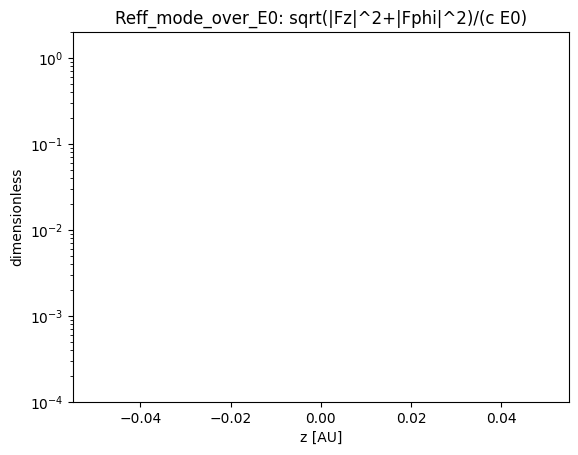

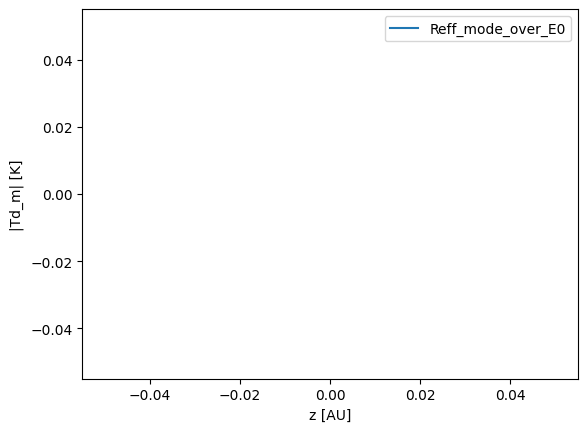

In [12]:
# Example: choose mode and shadow amplitude
m = 1
A_shadow = 2.0

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e4   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1000
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(zf)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

E0_bg = (4.0 * PI / C_LIGHT) * Jf

# (recommended) provide E0 from your background RT solution:
# E0_bg = (4*np.pi/C_LIGHT) * J0
# If you don't have it, you'll get fallback E0=a*T0^4 with a warning.

modes = ["frozen_lambda_bg", "Reff_mode_over_E0", "linear_causal_cap"]
modes = [ "Reff_mode_over_E0",]
results = {}

for mode in modes:
    E_m, Fz_m, Td_m, Tg_m, diag = solve_master_mode_shooting_compare(
        z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
        kappaP_func=kappaP, kappaR_func=kappaR,
        R=R, Omega=Omega, m=m,
        E0=E0_bg,
        A_shadow=A_shadow,
        gamma_g=gamma_g,
        c_d=c_d,
        beta_col_d=beta_col_d,
        beta_col_g=beta_col_g,
        beta_rad_d=None,
        limiter_mode=mode,
        # for linear_causal_cap:
        Hz=Hscale*np.ones_like(zf),   # or your z-dependent H
        Lz_mode="H",
        verbose=True
    )
    results[mode] = (E_m, Fz_m, Td_m, Tg_m, diag)

# Diagnostics: reduced-flux-like measures using background energy scale
import matplotlib.pyplot as plt

for mode, (E_m, Fz_m, Td_m, Tg_m, diag) in results.items():
    Fphi_m = diag["Fphi"]
    # "mode reduced flux" scaled by c E0 (background positive)
    ftot = np.sqrt(np.abs(Fz_m)**2 + np.abs(Fphi_m)**2) / (C_LIGHT*diag["E0_used"] + 1e-300)

    plt.figure()
    plt.semilogy(zf/AU, ftot)
    plt.title(f"{mode}: sqrt(|Fz|^2+|Fphi|^2)/(c E0)")
    plt.xlabel("z [AU]")
    plt.ylabel("dimensionless")
    plt.ylim(1e-4, 2.0)

# Compare Td_m amplitude
plt.figure()
for mode, (E_m, Fz_m, Td_m, Tg_m, diag) in results.items():
    plt.plot(zf/AU, np.abs(Td_m), label=mode)
plt.xlabel("z [AU]")
plt.ylabel("|Td_m| [K]")
plt.legend()
plt.show()


In [21]:
import numpy as np

C_LIGHT  = 2.99792458e10
SIGMA_SB = 5.670374419e-5
PI       = np.pi
A_RAD    = 4.0 * SIGMA_SB / C_LIGHT  # radiation constant a_R


def lambda_LP(R):
    """
    Levermore-Pomraning limiter, stable implementation.
    lambda(R) = (1/R)(coth R - 1/R)
    """
    R = np.asarray(R, float)
    out = np.empty_like(R)

    small = R < 1e-3
    large = R > 50.0
    mid = ~(small | large)

    out[small] = 1.0/3.0 - (R[small]**2)/15.0
    out[large] = (1.0/R[large]) * (1.0 - 1.0/R[large])

    coth = 1.0 / np.tanh(R[mid])
    out[mid] = (coth - 1.0/np.maximum(R[mid], 1e-300)) / np.maximum(R[mid], 1e-300)

    return np.clip(out, 0.0, 1.0)


def compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT=False):
    T0 = np.asarray(T0, float)
    kapP = np.asarray(kappaP_func(T0), float)

    if include_dkappa_dT:
        eps = 1e-3
        Tp = T0*(1+eps)
        Tm = T0*(1-eps)
        dk_dT = (kappaP_func(Tp) - kappaP_func(Tm)) / np.maximum(Tp-Tm, 1e-99)
        denom = 16.0*SIGMA_SB*kapP*T0**3 + 4.0*SIGMA_SB*dk_dT*T0**4
    else:
        denom = 16.0*SIGMA_SB*kapP*T0**3

    t_rad = c_d / np.maximum(denom, 1e-200)
    return Omega * t_rad


def _safe_hypot(a, b):
    """
    sqrt(a^2+b^2) without overflow: scale by max(a,b).
    a,b are nonnegative real floats.
    """
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.maximum(a, b)
    return m * np.sqrt((a/np.maximum(m, 1e-300))**2 + (b/np.maximum(m, 1e-300))**2)


def solve_master_mode_shooting_ReffPicard(
    z, rho_g, rho_d, T0, Q0,
    kappaP_func, kappaR_func,
    R, Omega, m,
    E0_bg,                         # REQUIRED for Reff normalization
    A_shadow=0.2,
    gamma_g=1.4,
    c_d=1.0e7,
    beta_col_d=None,
    beta_col_g=None,
    beta_rad_d=None,
    include_dkappa_dT=False,
    psi=1.0/np.sqrt(3.0),
    use_shadow_heating=True,
    # FLD iteration controls
    max_picard=50,
    tol_picard=1e-6,
    omega_D=0.3,                   # under-relax D update
    R_eff_max=1e6,                 # clamp Reff to avoid numeric pathologies
    D_min_factor=1e-6,             # D >= D_min_factor * D_thick
    # ODE integration controls
    verbose=False,
):
    """
    Reff-based FLD for one Fourier mode using Picard iteration on D(z).

    Outer loop: D^{k} -> solve linear ODE -> (E,Fz) -> Reff -> D^{k+1}.

    Returns: E_m, Fz_m, Td_m, Tg_m, diag
    """

    z = np.asarray(z, float)
    rho_g = np.asarray(rho_g, float)
    rho_d = np.asarray(rho_d, float)
    T0 = np.asarray(T0, float)
    Q0 = np.asarray(Q0, float)
    E0_bg = np.asarray(E0_bg, float)
    nz = len(z)

    m = int(m)
    ig = 1j

    if beta_col_d is None or beta_col_g is None:
        raise ValueError("Provide beta_col_d(z) and beta_col_g(z).")
    beta_col_d = np.asarray(beta_col_d, float)
    beta_col_g = np.asarray(beta_col_g, float)

    if beta_rad_d is None:
        beta_rad_d = compute_beta_rad_d(T0, kappaP_func, Omega, c_d, include_dkappa_dT)
    else:
        beta_rad_d = np.asarray(beta_rad_d, float)

    kapP0 = np.asarray(kappaP_func(T0), float)
    kapR0 = np.asarray(kappaR_func(T0), float)

    rho_eff = np.maximum(rho_d, 1e-99)
    kapP_eff = np.maximum(kapP0, 1e-99)
    kapR_eff = np.maximum(kapR0, 1e-99)

    # coefficients
    chi = rho_eff * kapP_eff * C_LIGHT
    eta = 4.0 * A_RAD * T0**3
    E0_bg = np.maximum(E0_bg, 1e-300)

    # heating mode
    Qm = (0.5 * A_shadow * Q0) if use_shadow_heating else Q0.copy()
    Theta = Qm / (rho_eff * c_d * Omega)

    # thick diffusion coefficient (lambda=1/3)
    D_thick = C_LIGHT / (3.0 * rho_eff * kapR_eff)

    # initial D guess: thick limit
    Dk = D_thick.copy()

    # --- algebra Td(E) ---
    def Td_Tg_from_E(E, i, Theta_loc):
        denom_g = 1.0 + ig*m*gamma_g*beta_col_g[i]
        D_T = (ig*m
               + 1.0/np.maximum(beta_rad_d[i], 1e-300)
               + (ig*m*gamma_g*beta_col_g[i]) / (np.maximum(beta_col_d[i],1e-300) * denom_g))
        Td = (Theta_loc + (1.0/np.maximum(beta_rad_d[i], 1e-300)) * (E/eta[i])) / D_T
        Tg = Td / denom_g
        return Td, Tg

    # --- linear ODE RHS given fixed D(z) ---
    def rhs_linear(i, E, Fz, forcing_on, Dprof):
        Theta_loc = Theta[i] if forcing_on else 0.0
        Td, _ = Td_Tg_from_E(E, i, Theta_loc)
        Duse = Dprof[i]
        dE_dz = -Fz / np.maximum(Duse, 1e-300)
        dFz_dz = chi[i]*(eta[i]*Td - E) - (Duse*(m**2)/np.maximum(R**2,1e-300))*E
        return dE_dz, dFz_dz

    def integrate(E0_guess, forcing_on, Dprof):
        E = np.zeros(nz, dtype=complex)
        F = np.zeros(nz, dtype=complex)
        E[0] = E0_guess
        F[0] = 0.0 + 0.0j

        for i in range(nz-1):
            dz = z[i+1] - z[i]
            Ei, Fi = E[i], F[i]

            k1E, k1F = rhs_linear(i, Ei, Fi, forcing_on, Dprof)

            E_half = Ei + 0.5*dz*k1E
            F_half = Fi + 0.5*dz*k1F
            k2E_i, k2F_i = rhs_linear(i,   E_half, F_half, forcing_on, Dprof)
            k2E_p, k2F_p = rhs_linear(i+1, E_half, F_half, forcing_on, Dprof)
            k2E, k2F = 0.5*(k2E_i+k2E_p), 0.5*(k2F_i+k2F_p)

            E_half2 = Ei + 0.5*dz*k2E
            F_half2 = Fi + 0.5*dz*k2F
            k3E_i, k3F_i = rhs_linear(i,   E_half2, F_half2, forcing_on, Dprof)
            k3E_p, k3F_p = rhs_linear(i+1, E_half2, F_half2, forcing_on, Dprof)
            k3E, k3F = 0.5*(k3E_i+k3E_p), 0.5*(k3F_i+k3F_p)

            E_end = Ei + dz*k3E
            F_end = Fi + dz*k3F
            k4E, k4F = rhs_linear(i+1, E_end, F_end, forcing_on, Dprof)

            E[i+1] = Ei + (dz/6.0)*(k1E + 2*k2E + 2*k3E + k4E)
            F[i+1] = Fi + (dz/6.0)*(k1F + 2*k2F + 2*k3F + k4F)

        return E, F

    # ---- Picard loop ----
    E = None
    Fz = None
    for it in range(max_picard):
        # linear shooting with current Dk
        Eh, Fh = integrate(1.0+0.0j, forcing_on=False, Dprof=Dk)
        Rh = Fh[-1] - psi*C_LIGHT*Eh[-1]

        Ep, Fp = integrate(0.0+0.0j, forcing_on=True,  Dprof=Dk)
        Rp = Fp[-1] - psi*C_LIGHT*Ep[-1]

        if np.abs(Rh) < 1e-120 or not np.isfinite(np.abs(Rh)):
            raise RuntimeError("Picard step failed: Rh ~ 0 or non-finite. Try reducing omega_D or clamp D.")

        E0 = -Rp / Rh
        E = E0*Eh + Ep
        Fz = E0*Fh + Fp

        # update D from Reff computed on this solution
        # use dE/dz from flux relation (consistent with fixed Dk used in this step)
        dE_dz = -Fz / np.maximum(Dk, 1e-300)
        grad_mag = _safe_hypot(np.abs(dE_dz), (m*np.abs(E)/np.maximum(R,1e-300)))

        R_eff = grad_mag / (rho_eff * kapR_eff * E0_bg)
        R_eff = np.clip(R_eff, 0.0, R_eff_max)

        lam = lambda_LP(R_eff)
        Dnew = (C_LIGHT * lam) / (rho_eff * kapR_eff)

        # keep D from collapsing too far (stability)
        Dmin = D_min_factor * D_thick
        Dnew = np.maximum(Dnew, Dmin)

        # under-relax
        Dk_next = (1.0-omega_D)*Dk + omega_D*Dnew

        # convergence measure on D
        rel = np.max(np.abs(Dk_next - Dk) / np.maximum(Dk, 1e-300))
        Dk = Dk_next

        if verbose and (it % 5 == 0 or rel < tol_picard):
            bc_err = Fz[-1] - psi*C_LIGHT*E[-1]
            bc_rel = np.abs(bc_err)/np.maximum(np.abs(psi*C_LIGHT*E[-1]), 1e-300)
            print(f"[Picard it={it:3d}] relD={rel:.3e}  bc_rel={bc_rel:.3e}  maxReff={np.max(R_eff):.3e}")

        if rel < tol_picard:
            break

    # recover Td,Tg with final E
    Td = np.zeros(nz, dtype=complex)
    Tg = np.zeros(nz, dtype=complex)
    for i in range(nz):
        Td[i], Tg[i] = Td_Tg_from_E(E[i], i, Theta[i])

    Fphi = -Dk * (ig*m/np.maximum(R,1e-300)) * E

    diag = dict(
        D_used=Dk,
        D_thick=D_thick,
        Reff=R_eff,
        lambda_used=lambda_LP(R_eff),
        Fphi=Fphi,
        Qm=Qm,
    )
    return E, Fz, Td, Tg, diag



# Example: choose mode and shadow amplitude
m = 1
A_shadow = 2.0

# Then beta_col,g follows from your heat capacity relation:
# beta_col,d = (rho_d/rho_g)*(c_d/c_v) * beta_col,g  => beta_col,g = beta_col,d * (rho_g/rho_d)*(c_v/c_d)
gamma_g = 1.4
c_v = 1.0e8   # set gas cv [erg g^-1 K^-1]
c_p = gamma_g * c_v
c_d = 1.0e4   # set dust c_d [erg g^-1 K^-1]

# Build beta_col arrays from your St prescription.
# You said: St = Omega t_s and t_col,d ∝ t_s, so beta_col,d ∝ St.
# For a simple model: beta_col,d(z) = C * St (constant with height).
St = 1000
Ccol_pref = 1.0  # set from your alpha_T^{-1}*(2/3)*(1/(gamma-1))*(c_d/c_v) etc.
beta_col_d = Ccol_pref * St * (c_d/c_v) *  np.ones_like(zf)

rho_d = rhof
rho_g = rhof * 100

beta_col_g = beta_col_d * (rho_g/rho_d) * (c_v/c_d)

G = 6.67430e-8
Msun = 1.98847e33
Ms = 1.0 * Msun
Omega = np.sqrt(G * Ms / R**3)

E0_bg = (4.0 * PI / C_LIGHT) * Jf
# You MUST give a background E0_bg that is positive and smooth.
# If you have J0 from MEMO: E0_bg = (4*np.pi/C_LIGHT) * J0
# If not, as a rough fallback: E0_bg = A_RAD * Tf**4  (less accurate in thin layers)

E_m, Fz_m, Td_m, Tg_m, diag = solve_master_mode_shooting_ReffPicard(
    z=zf, rho_g=rho_g, rho_d=rho_d, T0=Tf, Q0=qf,
    kappaP_func=kappaP, kappaR_func=kappaR,
    R=R, Omega=Omega, m=m,
    E0_bg=E0_bg,
    A_shadow=A_shadow,
    gamma_g=gamma_g,
    c_d=c_d,
    beta_col_d=beta_col_d,
    beta_col_g=beta_col_g,
    beta_rad_d=None,
    verbose=True,
    omega_D=0.2,         # start small
    R_eff_max=1e4,       # start conservative
    D_min_factor=1e-4,   # prevent collapse
)


[Picard it=  0] relD=1.999e-01  bc_rel=3.195e+28  maxReff=1.000e+04
[Picard it=  5] relD=4.100e-01  bc_rel=6.144e+26  maxReff=1.000e+04
[Picard it= 10] relD=1.997e-01  bc_rel=7.680e+25  maxReff=1.000e+04
[Picard it= 15] relD=5.422e+00  bc_rel=7.680e+25  maxReff=1.000e+04
[Picard it= 20] relD=1.659e+01  bc_rel=1.920e+25  maxReff=1.000e+04
[Picard it= 25] relD=2.074e+00  bc_rel=6.442e+32  maxReff=1.000e+04
[Picard it= 30] relD=4.394e-01  bc_rel=1.600e+24  maxReff=1.000e+04
[Picard it= 35] relD=1.063e+00  bc_rel=3.427e+16  maxReff=1.000e+04
[Picard it= 40] relD=4.618e+02  bc_rel=1.010e+24  maxReff=1.000e+04
[Picard it= 45] relD=1.366e+01  bc_rel=5.923e+16  maxReff=1.000e+04


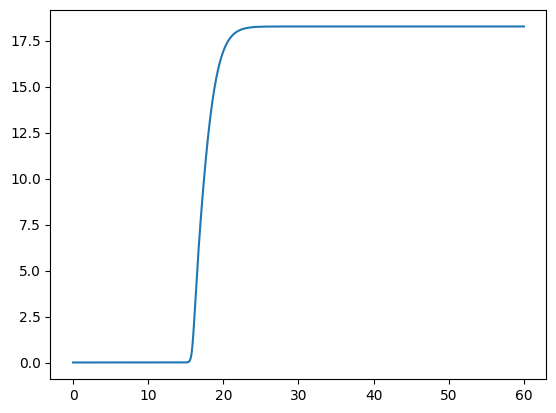

In [22]:
plt.plot(zf/AU, np.abs(Td_m), label=mode)